In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os

warnings.filterwarnings('ignore')

# ── Output folder for saving charts ──────────────────────────────────────────
os.makedirs('../outputs/eda_charts', exist_ok=True)

# ── Consistent colour palette per channel ────────────────────────────────────
# Using the same colours everywhere makes dashboards readable at a glance.
# A viewer should never have to re-read the legend.
CHANNEL_COLORS = {
    'Google Search':        '#4285F4',   # Google blue
    'Meta Ads':             '#1877F2',   # Meta blue (lighter)
    'Programmatic Display': '#FF6B35',   # Orange — awareness channel
    'YouTube':              '#FF0000',   # YouTube red
    'Affiliate':            '#34A853',   # Green — performance channel
}

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

print("Libraries loaded. Ready for EDA.")

Libraries loaded. Ready for EDA.


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/campaign_data.csv', parse_dates=['date'])
anomaly_gt = pd.read_csv('../data/ground_truth_anomalies.csv', parse_dates=['date'])

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape:          {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date range:     {df['date'].min().date()} to {df['date'].max().date()}")
print(f"  Channels:       {df['channel'].nunique()} — {list(df['channel'].unique())}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows: {df.duplicated().sum()}")
print()

# ── Column summary ────────────────────────────────────────────────────────────
print("COLUMN TYPES")
print(df.dtypes.to_string())
print()

# ── Statistical summary ───────────────────────────────────────────────────────
# Round to 2dp so it's readable — raw .describe() output has too many decimals
numeric_cols = ['spend', 'impressions', 'clicks', 'conversions',
                'revenue', 'ctr', 'cvr', 'cpc', 'roas', 'cost_per_conversion']

print("\nSTATISTICAL SUMMARY")
print(df[numeric_cols].describe().round(2).to_string())

DATASET OVERVIEW
  Shape:          2,740 rows × 19 columns
  Date range:     2023-01-01 to 2024-07-01
  Channels:       5 — ['Google Search', 'Meta Ads', 'Programmatic Display', 'YouTube', 'Affiliate']
  Missing values: 2676
  Duplicate rows: 0

COLUMN TYPES
date                   datetime64[ns]
channel                        object
spend                         float64
impressions                     int64
clicks                          int64
conversions                     int64
revenue                       float64
ctr                           float64
cvr                           float64
cpc                           float64
roas                          float64
cost_per_conversion           float64
seasonality_factor            float64
day_of_week                    object
month                           int64
year                            int64
week_number                     int64
is_weekend                      int64
anomaly_type                   object


STATISTICAL SUMMA

In [3]:
print("=" * 55)
print("DATA QUALITY AUDIT")
print("=" * 55)

quality_log = []

# ── Check 1: Logical impossible values ───────────────────────────────────────
bad_ctr = df[df['clicks'] > df['impressions']]
bad_cvr = df[df['conversions'] > df['clicks']]
neg_spend = df[df['spend'] < 0]
neg_revenue = df[df['revenue'] < 0]

checks = [
    ("Clicks > impressions",    len(bad_ctr)),
    ("Conversions > clicks",    len(bad_cvr)),
    ("Negative spend",          len(neg_spend)),
    ("Negative revenue",        len(neg_revenue)),
]

for label, count in checks:
    status = "PASS" if count == 0 else "FAIL"
    print(f"  [{status}] {label}: {count} rows")
    quality_log.append({'check': label, 'status': status, 'count': count})

# ── Check 2: Extreme ROAS (> 50x) ────────────────────────────────────────────
extreme_roas = df[df['roas'] > 50]
print(f"\n  [INFO] ROAS > 50x: {len(extreme_roas)} rows")
if len(extreme_roas) > 0:
    print(extreme_roas[['date', 'channel', 'spend', 'revenue', 'roas']].to_string(index=False))

# ── Check 3: Zero-spend days per channel ─────────────────────────────────────
zero_spend = df[df['spend'] == 0].groupby('channel').size()
print(f"\n  Zero-spend rows by channel:")
print(zero_spend.to_string() if len(zero_spend) > 0 else "  None — all channels have spend every day")

# ── Check 4: CTR outliers (> 25%) ────────────────────────────────────────────
# CTR above 25% is unrealistic for any paid channel
high_ctr = df[df['ctr'] > 0.25]
print(f"\n  [INFO] CTR > 25%: {len(high_ctr)} rows")

# ── Check 5: CPC = 0 on non-affiliate rows ───────────────────────────────────
# Affiliate is cost-per-acquisition so CPC=0 is expected there
# For all other channels, CPC=0 means zero clicks — should only happen on Zero Traffic days
non_aff_zero_cpc = df[(df['channel'] != 'Affiliate') & 
                       (df['cpc'] == 0) & 
                       (df['anomaly_type'] == 'None')]
print(f"\n  [INFO] CPC=0 on non-Affiliate rows (excluding known anomalies): {len(non_aff_zero_cpc)}")

# ── Save quality log ──────────────────────────────────────────────────────────
quality_df = pd.DataFrame(quality_log)
quality_df.to_csv('../outputs/data_quality_log.csv', index=False)
print("\n  Saved: outputs/data_quality_log.csv")
print("\nData quality audit complete.")

DATA QUALITY AUDIT
  [PASS] Clicks > impressions: 0 rows
  [PASS] Conversions > clicks: 0 rows
  [PASS] Negative spend: 0 rows
  [PASS] Negative revenue: 0 rows

  [INFO] ROAS > 50x: 532 rows
      date   channel    spend    revenue    roas
2023-01-01 Affiliate  1223.67   73022.70  59.675
2023-01-02 Affiliate  1200.60  137835.10 114.806
2023-01-03 Affiliate  1391.37  237720.61 170.854
2023-01-04 Affiliate  1798.01  111624.04  62.082
2023-01-05 Affiliate   990.42  134846.19 136.150
2023-01-06 Affiliate  1837.90  369694.37 201.151
2023-01-07 Affiliate   895.08  188975.33 211.127
2023-01-08 Affiliate   916.19   87328.11  95.317
2023-01-09 Affiliate  1760.36  171883.80  97.641
2023-01-10 Affiliate   913.91  259793.46 284.265
2023-01-11 Affiliate   768.72  103428.93 134.546
2023-01-13 Affiliate  1666.35  229838.42 137.929
2023-01-14 Affiliate   824.93   51863.99  62.871
2023-01-15 Affiliate   700.59   96428.29 137.639
2023-01-16 Affiliate  1283.77  222890.24 173.621
2023-01-17 Affiliate  12

In [4]:
print("=" * 55)
print("BUSINESS QUESTION 1:")
print("Which channel delivers the highest return per rupee?")
print("=" * 55)

channel_summary = df.groupby('channel').agg(
    Total_Spend          = ('spend',              'sum'),
    Total_Revenue        = ('revenue',            'sum'),
    Total_Impressions    = ('impressions',         'sum'),
    Total_Clicks         = ('clicks',              'sum'),
    Total_Conversions    = ('conversions',         'sum'),
    Avg_ROAS             = ('roas',               'mean'),
    Avg_CPC              = ('cpc',                'mean'),
    Avg_CTR              = ('ctr',                'mean'),
    Avg_CVR              = ('cvr',                'mean'),
    Avg_Cost_Per_Conv    = ('cost_per_conversion', 'mean'),
).round(3)

# ── Derived metrics ───────────────────────────────────────────────────────────
channel_summary['Overall_ROAS']         = (channel_summary['Total_Revenue'] /
                                            channel_summary['Total_Spend']).round(2)
channel_summary['Spend_Share_Pct']      = (channel_summary['Total_Spend'] /
                                            channel_summary['Total_Spend'].sum() * 100).round(1)
channel_summary['Revenue_Share_Pct']    = (channel_summary['Total_Revenue'] /
                                            channel_summary['Total_Revenue'].sum() * 100).round(1)
channel_summary['Efficiency_Score']     = (
    channel_summary['Overall_ROAS'] * 0.4 +
    (1 / channel_summary['Avg_Cost_Per_Conv'].replace(0, np.nan)) * 1000 * 0.4 +
    channel_summary['Avg_CVR'] * 100 * 0.2
).round(2)

# ── Sort by ROAS and display ──────────────────────────────────────────────────
display_cols = ['Total_Spend', 'Total_Revenue', 'Overall_ROAS',
                'Spend_Share_Pct', 'Revenue_Share_Pct',
                'Avg_CPC', 'Avg_CVR', 'Total_Conversions', 'Efficiency_Score']

summary_display = channel_summary[display_cols].sort_values('Overall_ROAS', ascending=False)

# Format for readability
summary_display['Total_Spend']   = summary_display['Total_Spend'].apply(lambda x: f"Rs.{x:,.0f}")
summary_display['Total_Revenue'] = summary_display['Total_Revenue'].apply(lambda x: f"Rs.{x:,.0f}")
summary_display['Avg_CVR']       = summary_display['Avg_CVR'].apply(lambda x: f"{x:.2%}")

print(summary_display.to_string())

# ── Save ──────────────────────────────────────────────────────────────────────
channel_summary.to_csv('../outputs/channel_efficiency_summary.csv')
print("\nSaved: outputs/channel_efficiency_summary.csv")

# ── Business commentary ───────────────────────────────────────────────────────
top_roas    = channel_summary['Overall_ROAS'].idxmax()
worst_roas  = channel_summary['Overall_ROAS'].idxmin()
top_spend   = channel_summary['Total_Spend'].idxmax()

print(f"""
BUSINESS INSIGHT:
  -> {top_roas} has the highest ROAS at {channel_summary.loc[top_roas, 'Overall_ROAS']:.2f}x
     This is your most efficient channel — every rupee earns {channel_summary.loc[top_roas, 'Overall_ROAS']:.2f}x back.

  -> {worst_roas} has the lowest ROAS at {channel_summary.loc[worst_roas, 'Overall_ROAS']:.2f}x
     This channel is underperforming. Is it an awareness channel (OK) or
     a bottom-funnel channel (problem)?

  -> {top_spend} receives the largest share of budget at
     {channel_summary.loc[top_spend, 'Spend_Share_Pct']:.1f}% of total spend.
     Is its revenue share proportional? If not, there's a reallocation opportunity.
""")

BUSINESS QUESTION 1:
Which channel delivers the highest return per rupee?
                       Total_Spend   Total_Revenue  Overall_ROAS  Spend_Share_Pct  Revenue_Share_Pct  Avg_CPC Avg_CVR  Total_Conversions  Efficiency_Score
channel                                                                                                                                                   
Affiliate               Rs.908,447  Rs.127,280,541        140.11              9.8               89.0    0.829   6.00%              76202             85.34
Meta Ads              Rs.2,388,814    Rs.4,779,593          2.00             25.8                3.3   20.563   2.20%               2916              1.65
Google Search         Rs.3,092,540    Rs.6,116,967          1.98             33.4                4.3   36.270   4.10%               3756              2.06
Programmatic Display  Rs.1,574,310    Rs.2,916,288          1.85             17.0                2.0    9.034   0.80%               1733              1

CHART 1: Monthly spend trend per channel
Business question: When does each channel ramp up and pull back?


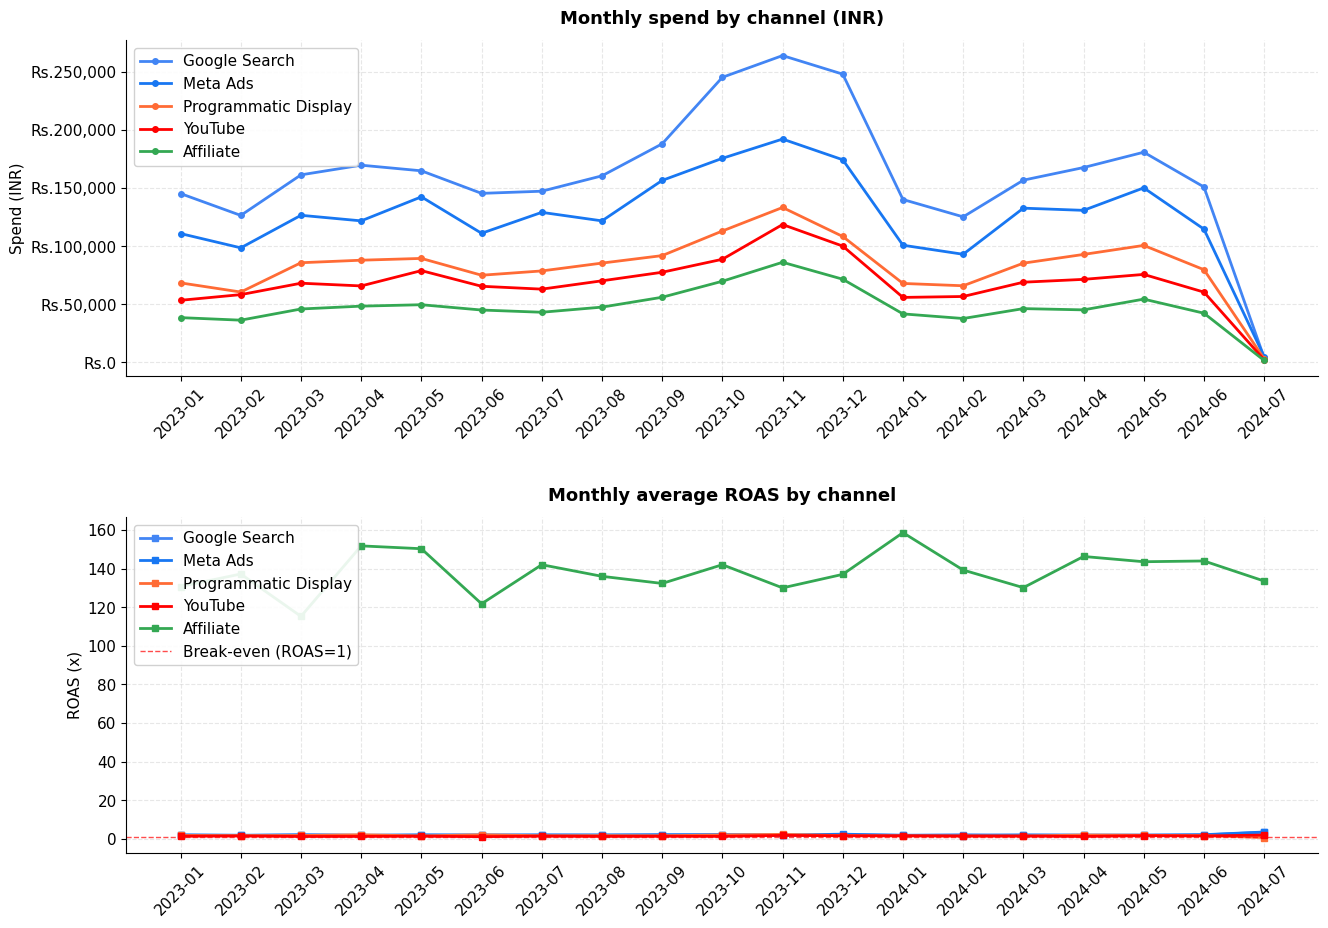


Saved: outputs/eda_charts/01_monthly_spend_roas_trend.png

BUSINESS INSIGHT:
  -> The Nov 2023 peak is the Diwali effect — spend and ROAS both spike.
  -> Any channel whose ROAS dips below the red line (1.0x) is losing money.
  -> If ROAS drops while spend rises, it means more budget is chasing
     the same audience — diminishing returns kicking in.



In [5]:
print("CHART 1: Monthly spend trend per channel")
print("Business question: When does each channel ramp up and pull back?")

# ── Aggregate to monthly ──────────────────────────────────────────────────────
df['month_period'] = df['date'].dt.to_period('M')
monthly = df.groupby(['month_period', 'channel']).agg(
    spend       = ('spend',       'sum'),
    revenue     = ('revenue',     'sum'),
    conversions = ('conversions', 'sum'),
    roas        = ('roas',        'mean'),
).reset_index()
monthly['month_str'] = monthly['month_period'].astype(str)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top panel — spend
for channel in df['channel'].unique():
    ch_data = monthly[monthly['channel'] == channel].sort_values('month_str')
    axes[0].plot(
        ch_data['month_str'],
        ch_data['spend'],
        marker='o',
        markersize=4,
        linewidth=2,
        label=channel,
        color=CHANNEL_COLORS[channel]
    )

axes[0].set_title('Monthly spend by channel (INR)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Spend (INR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left', framealpha=0.9)

# Bottom panel — ROAS trend
for channel in df['channel'].unique():
    ch_data = monthly[monthly['channel'] == channel].sort_values('month_str')
    axes[1].plot(
        ch_data['month_str'],
        ch_data['roas'],
        marker='s',
        markersize=4,
        linewidth=2,
        label=channel,
        color=CHANNEL_COLORS[channel]
    )

axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Break-even (ROAS=1)')
axes[1].set_title('Monthly average ROAS by channel', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('ROAS (x)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', framealpha=0.9)

plt.tight_layout(pad=3)
plt.savefig('../outputs/eda_charts/01_monthly_spend_roas_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: outputs/eda_charts/01_monthly_spend_roas_trend.png")
print("""
BUSINESS INSIGHT:
  -> The Nov 2023 peak is the Diwali effect — spend and ROAS both spike.
  -> Any channel whose ROAS dips below the red line (1.0x) is losing money.
  -> If ROAS drops while spend rises, it means more budget is chasing
     the same audience — diminishing returns kicking in.
""")

CHART 2: ROAS heatmap — channel × month
Business question: Which channel performs best in which season?
This single chart drives budget reallocation decisions worth lakhs.


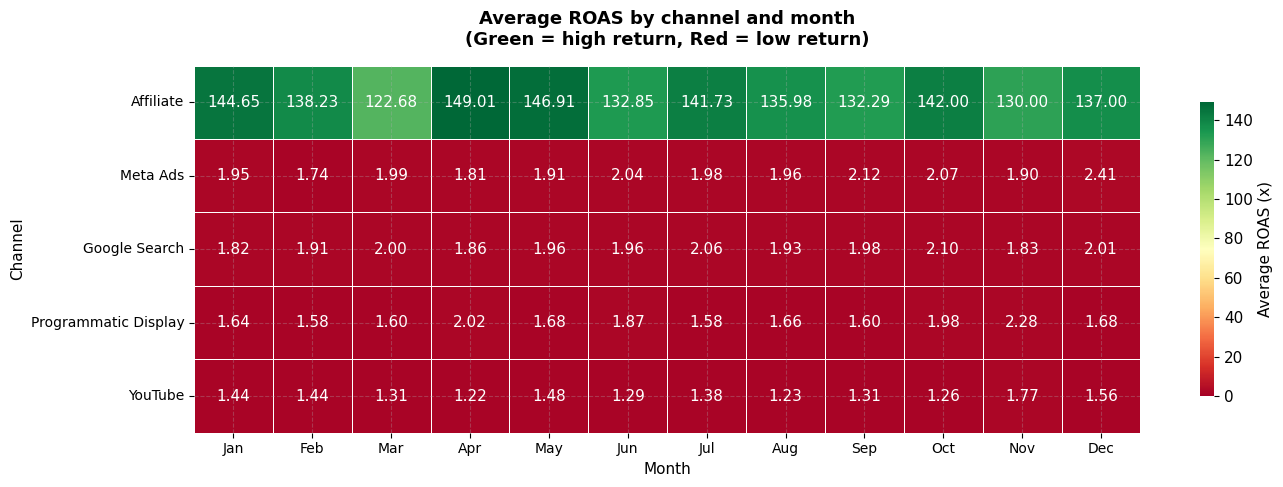


Saved: outputs/eda_charts/02_roas_heatmap.png

BUSINESS INSIGHT:
  -> Apr is the highest ROAS month overall — this is when
     every additional rupee of spend earns the most. Brands should
     INCREASE budgets here, not hold flat.

  -> Mar is the weakest month — consider pulling back
     and shifting budget to higher-return months.

  -> Affiliate consistently shows strong ROAS.
     If it has budget headroom, it's the first place to invest more.

  -> Programmatic Display red cells = awareness investment, not ROI play.
     That's acceptable IF the brief is reach, not conversion.
     If the brief is conversion, cut it.

THIS CHART IS PORTFOLIO GOLD — screenshot it for your LinkedIn post.



In [6]:
print("CHART 2: ROAS heatmap — channel × month")
print("Business question: Which channel performs best in which season?")
print("This single chart drives budget reallocation decisions worth lakhs.")

# ── Pivot table ───────────────────────────────────────────────────────────────
roas_pivot = df.pivot_table(
    values   = 'roas',
    index    = 'channel',
    columns  = 'month',
    aggfunc  = 'mean'
).round(2)

# Rename columns to month names for readability
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
roas_pivot.columns = [month_names[m] for m in roas_pivot.columns]

# Sort channels by average ROAS (best at top)
roas_pivot = roas_pivot.loc[roas_pivot.mean(axis=1).sort_values(ascending=False).index]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    roas_pivot,
    annot     = True,
    fmt       = '.2f',
    cmap      = 'RdYlGn',       # Red = low ROAS, Green = high ROAS
    linewidths = 0.5,
    linecolor  = 'white',
    ax         = ax,
    vmin       = 0,
    vmax       = roas_pivot.max().max(),
    cbar_kws   = {'label': 'Average ROAS (x)', 'shrink': 0.8}
)

ax.set_title('Average ROAS by channel and month\n(Green = high return, Red = low return)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Channel', fontsize=11)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('../outputs/eda_charts/02_roas_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: outputs/eda_charts/02_roas_heatmap.png")

# ── Business commentary ───────────────────────────────────────────────────────
best_month    = roas_pivot.mean().idxmax()
worst_month   = roas_pivot.mean().idxmin()
best_channel  = roas_pivot.mean(axis=1).idxmax()

print(f"""
BUSINESS INSIGHT:
  -> {best_month} is the highest ROAS month overall — this is when
     every additional rupee of spend earns the most. Brands should
     INCREASE budgets here, not hold flat.

  -> {worst_month} is the weakest month — consider pulling back
     and shifting budget to higher-return months.

  -> {best_channel} consistently shows strong ROAS.
     If it has budget headroom, it's the first place to invest more.

  -> Programmatic Display red cells = awareness investment, not ROI play.
     That's acceptable IF the brief is reach, not conversion.
     If the brief is conversion, cut it.

THIS CHART IS PORTFOLIO GOLD — screenshot it for your LinkedIn post.
""")

In [7]:
print("CHART 3: Spend efficiency scatter — every day, every channel")
print("Business question: Are high-spend days also high-ROAS days, or is there waste?")

fig = px.scatter(
    df[df['spend'] > 100],                  # Filter near-zero spend (Zero Traffic anomalies)
    x          = 'spend',
    y          = 'roas',
    color      = 'channel',
    color_discrete_map = CHANNEL_COLORS,
    opacity    = 0.45,
    size       = 'conversions',
    size_max   = 18,
    hover_data = ['date', 'channel', 'spend', 'revenue', 'conversions', 'anomaly_type'],
    labels     = {'spend': 'Daily Spend (INR)', 'roas': 'ROAS (x)', 'channel': 'Channel'},
    title      = 'Daily spend vs ROAS by channel (bubble size = conversions)',
)

fig.add_hline(
    y          = 1.0,
    line_dash  = 'dash',
    line_color = 'red',
    annotation_text = 'Break-even line (ROAS = 1)',
    annotation_position = 'top right'
)

fig.update_layout(
    height      = 550,
    plot_bgcolor = 'white',
    paper_bgcolor = 'white',
    legend_title  = 'Channel',
)

fig.write_html('../outputs/eda_charts/03_spend_roas_scatter.html')
fig.show()

print("\nSaved: outputs/eda_charts/03_spend_roas_scatter.html (interactive)")
print("""
BUSINESS INSIGHT:
  -> Points below the red line = days where the channel LOST money (revenue < spend).
  -> Large bubbles above the line = high-volume, profitable days — replicate these.
  -> Clusters of small bubbles at high spend but low ROAS = budget being wasted
     on low-quality inventory or audiences.
  -> Hover over any outlier point — it shows the exact date. Cross-reference
     with your anomaly log to understand why.
""")

CHART 3: Spend efficiency scatter — every day, every channel
Business question: Are high-spend days also high-ROAS days, or is there waste?



Saved: outputs/eda_charts/03_spend_roas_scatter.html (interactive)

BUSINESS INSIGHT:
  -> Points below the red line = days where the channel LOST money (revenue < spend).
  -> Large bubbles above the line = high-volume, profitable days — replicate these.
  -> Clusters of small bubbles at high spend but low ROAS = budget being wasted
     on low-quality inventory or audiences.
  -> Hover over any outlier point — it shows the exact date. Cross-reference
     with your anomaly log to understand why.



CHART 4: Rolling CPC trend with spike detection
Business question: Which channels had bid strategy failures, and when?
  CPC spikes detected: 18 across all channels
  Breakdown by channel:
channel
Affiliate               7
Google Search           1
Meta Ads                4
Programmatic Display    3
YouTube                 3


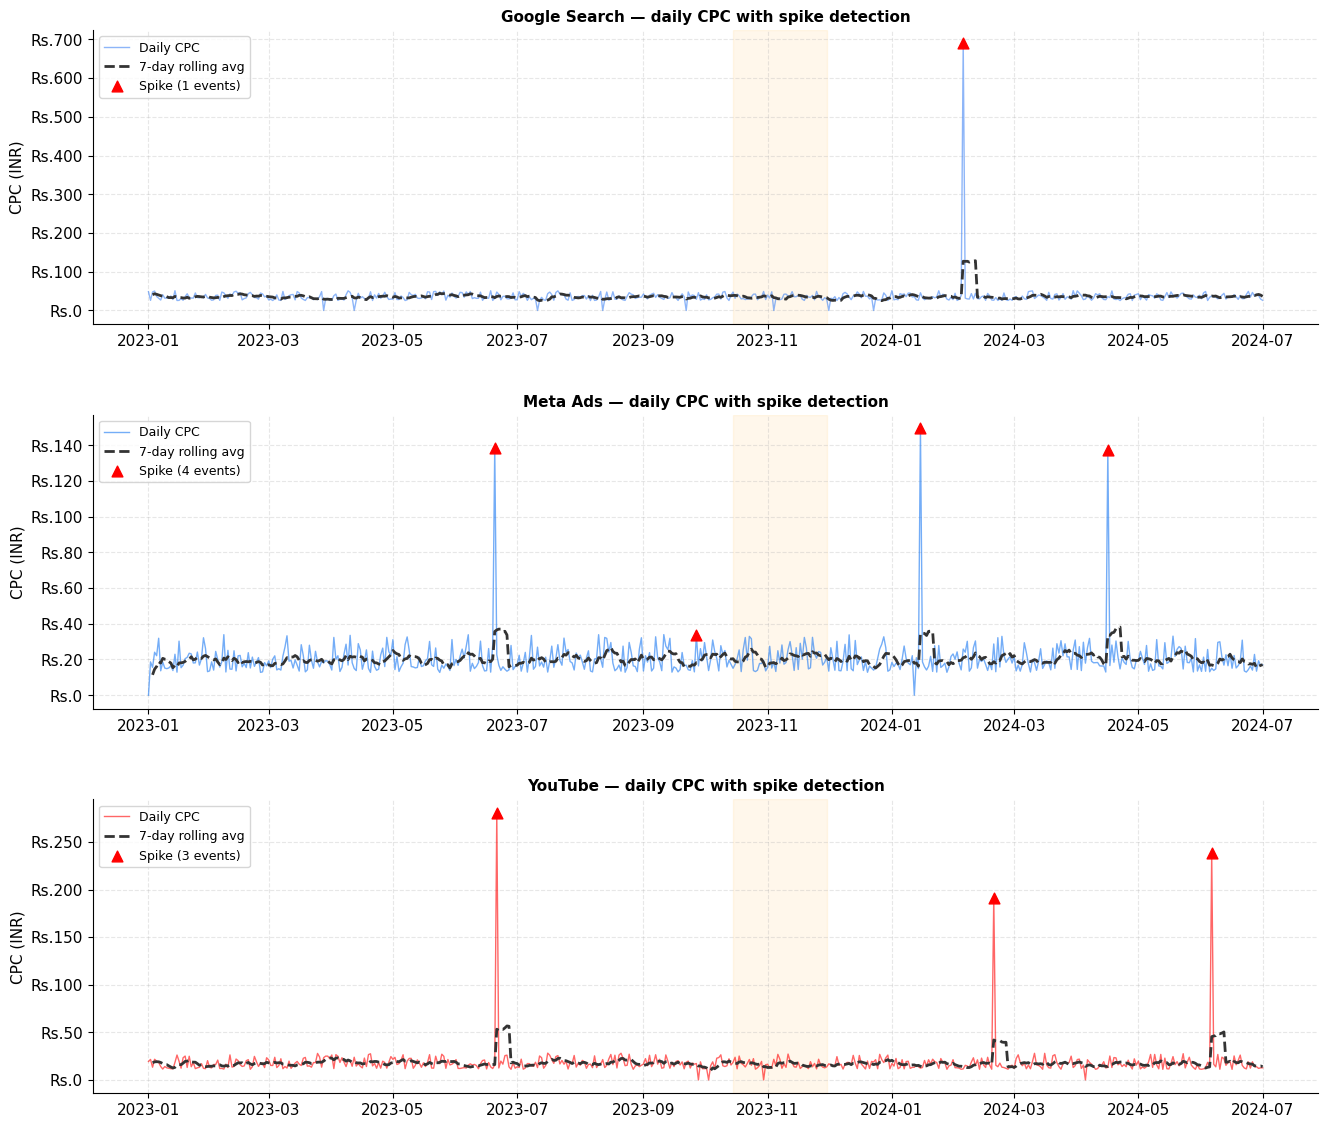


Saved: outputs/eda_charts/04_cpc_spike_detection.png
Saved: outputs/cpc_spike_log.csv

BUSINESS INSIGHT:
  -> Red triangle = day where CPC jumped > 80% above its recent average.
     Likely causes: competitor entered the auction, broad match keyword
     triggered irrelevant expensive queries, or automated bidding went rogue.

  -> CPC spikes during the festive shaded window are EXPECTED —
     all brands bid more aggressively in Oct–Nov.
  -> CPC spikes in Jan or Jul are NOT expected — those need investigation.

  -> Practical action: set CPC cap alerts in Google/Meta Ads Manager
     so these get flagged same-day, not in monthly reports.



In [8]:
print("CHART 4: Rolling CPC trend with spike detection")
print("Business question: Which channels had bid strategy failures, and when?")

# ── Compute rolling 7-day CPC per channel ────────────────────────────────────
df_sorted = df.sort_values(['channel', 'date']).copy()

df_sorted['rolling_cpc_7d'] = df_sorted.groupby('channel')['cpc'].transform(
    lambda x: x.rolling(window=7, min_periods=3).mean()
)

df_sorted['cpc_ratio'] = df_sorted['cpc'] / df_sorted['rolling_cpc_7d'].replace(0, np.nan)

# Flag as spike if CPC is > 1.8x its rolling 7-day average
# 1.8x threshold = 80% above normal — material enough to warrant investigation
df_sorted['cpc_spike'] = df_sorted['cpc_ratio'] > 1.8

spikes = df_sorted[df_sorted['cpc_spike'] == True]
print(f"  CPC spikes detected: {len(spikes)} across all channels")
print(f"  Breakdown by channel:\n{spikes.groupby('channel').size().to_string()}")

# ── Plot for each channel ─────────────────────────────────────────────────────
channels_to_plot = ['Google Search', 'Meta Ads', 'YouTube']   # CPC-based only

fig, axes = plt.subplots(len(channels_to_plot), 1,
                          figsize=(14, 4 * len(channels_to_plot)))

for idx, channel in enumerate(channels_to_plot):
    ch = df_sorted[df_sorted['channel'] == channel].sort_values('date')
    ax = axes[idx]

    # Daily CPC line
    ax.plot(ch['date'], ch['cpc'],
            color=CHANNEL_COLORS[channel], linewidth=1, alpha=0.6, label='Daily CPC')

    # Rolling average
    ax.plot(ch['date'], ch['rolling_cpc_7d'],
            color='#333333', linewidth=2, linestyle='--', label='7-day rolling avg')

    # Spike markers
    ch_spikes = ch[ch['cpc_spike'] == True]
    ax.scatter(ch_spikes['date'], ch_spikes['cpc'],
               color='red', zorder=5, s=60, label=f'Spike ({len(ch_spikes)} events)', marker='^')

    ax.set_title(f'{channel} — daily CPC with spike detection',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('CPC (INR)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x:.0f}'))
    ax.legend(loc='upper left', fontsize=9)

    # Shade Diwali period (Oct 15 – Nov 30 both years)
    for year in [2023]:
        ax.axvspan(pd.Timestamp(f'{year}-10-15'), pd.Timestamp(f'{year}-11-30'),
                   alpha=0.08, color='orange', label='Festive season')

plt.tight_layout(pad=3)
plt.savefig('../outputs/eda_charts/04_cpc_spike_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save spike log ────────────────────────────────────────────────────────────
spike_cols = ['date', 'channel', 'cpc', 'rolling_cpc_7d', 'cpc_ratio', 'spend']
spikes[spike_cols].to_csv('../outputs/cpc_spike_log.csv', index=False)
print("\nSaved: outputs/eda_charts/04_cpc_spike_detection.png")
print("Saved: outputs/cpc_spike_log.csv")
print("""
BUSINESS INSIGHT:
  -> Red triangle = day where CPC jumped > 80% above its recent average.
     Likely causes: competitor entered the auction, broad match keyword
     triggered irrelevant expensive queries, or automated bidding went rogue.

  -> CPC spikes during the festive shaded window are EXPECTED —
     all brands bid more aggressively in Oct–Nov.
  -> CPC spikes in Jan or Jul are NOT expected — those need investigation.

  -> Practical action: set CPC cap alerts in Google/Meta Ads Manager
     so these get flagged same-day, not in monthly reports.
""")

CHART 5: Weekday vs weekend performance patterns
Business question: Should we reduce budgets on weekends?


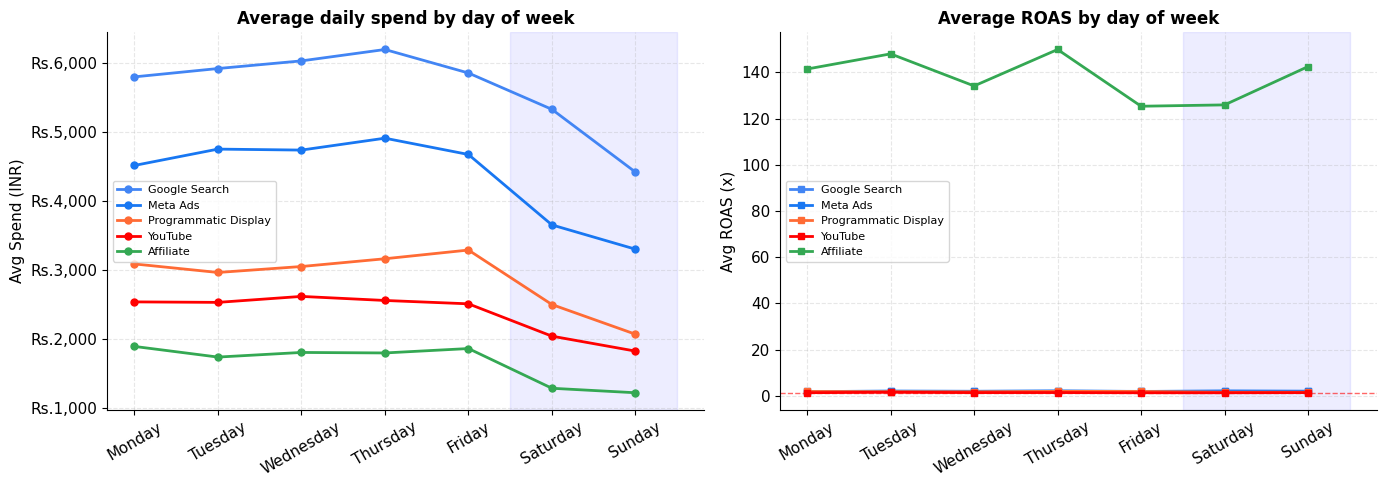


Saved: outputs/eda_charts/05_dow_performance.png

BUSINESS INSIGHT:
  -> If weekend ROAS is lower but spend is also lower, that's acceptable.
  -> If weekend ROAS is lower but spend is NOT lower, that's a budget efficiency problem.
  -> The business recommendation depends on the brand:
       B2C: Weekends can be strong (consumers browse on Sat/Sun)
       B2B: Cut weekends aggressively — decision-makers aren't working



In [9]:
print("CHART 5: Weekday vs weekend performance patterns")
print("Business question: Should we reduce budgets on weekends?")

dow_summary = df.groupby(['day_of_week', 'channel']).agg(
    avg_spend       = ('spend',       'mean'),
    avg_roas        = ('roas',        'mean'),
    avg_cpc         = ('cpc',         'mean'),
    avg_cvr         = ('cvr',         'mean'),
    avg_conversions = ('conversions', 'mean'),
).round(3).reset_index()

# Order days correctly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary['day_of_week'] = pd.Categorical(
    dow_summary['day_of_week'], categories=day_order, ordered=True
)
dow_summary = dow_summary.sort_values('day_of_week')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: avg spend by day
for channel in df['channel'].unique():
    ch_data = dow_summary[dow_summary['channel'] == channel]
    axes[0].plot(
        ch_data['day_of_week'].astype(str),
        ch_data['avg_spend'],
        marker='o', linewidth=2, markersize=5,
        label=channel, color=CHANNEL_COLORS[channel]
    )

axes[0].set_title('Average daily spend by day of week', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Spend (INR)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rs.{x:,.0f}'))
axes[0].legend(fontsize=8)
axes[0].axvspan(4.5, 6.5, alpha=0.07, color='blue', label='Weekend')

# Right: avg ROAS by day
for channel in df['channel'].unique():
    ch_data = dow_summary[dow_summary['channel'] == channel]
    axes[1].plot(
        ch_data['day_of_week'].astype(str),
        ch_data['avg_roas'],
        marker='s', linewidth=2, markersize=5,
        label=channel, color=CHANNEL_COLORS[channel]
    )

axes[1].set_title('Average ROAS by day of week', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg ROAS (x)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(fontsize=8)
axes[1].axvspan(4.5, 6.5, alpha=0.07, color='blue', label='Weekend')
axes[1].axhline(y=1.0, color='red', linestyle='--', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig('../outputs/eda_charts/05_dow_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: outputs/eda_charts/05_dow_performance.png")
print("""
BUSINESS INSIGHT:
  -> If weekend ROAS is lower but spend is also lower, that's acceptable.
  -> If weekend ROAS is lower but spend is NOT lower, that's a budget efficiency problem.
  -> The business recommendation depends on the brand:
       B2C: Weekends can be strong (consumers browse on Sat/Sun)
       B2B: Cut weekends aggressively — decision-makers aren't working
""")

CHART 6: Channel performance correlation matrix
Business question: Do channels move together, or do some offset others?


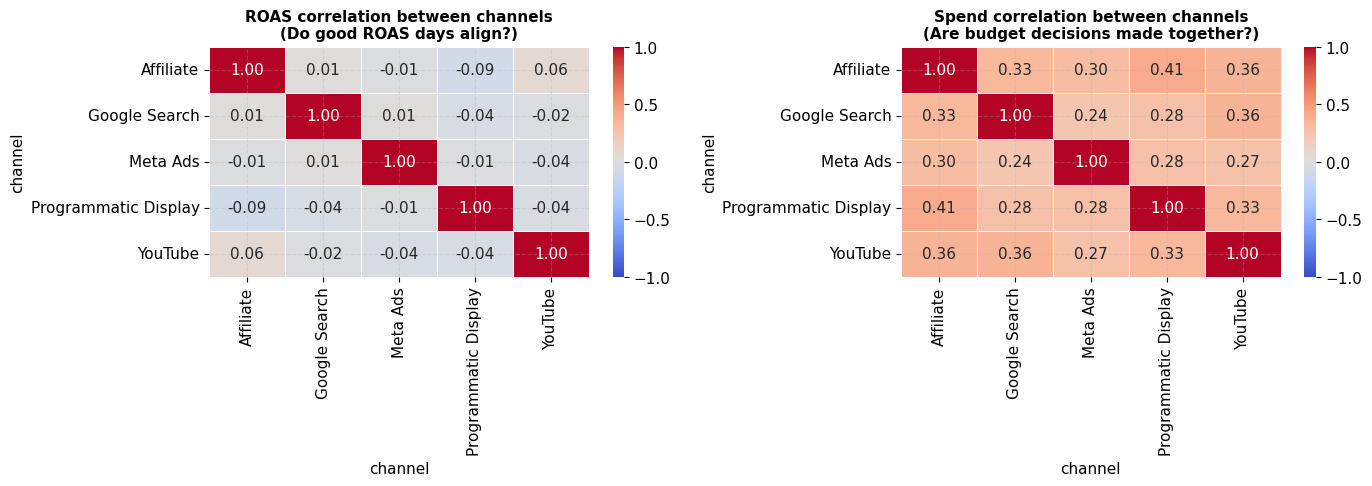


Saved: outputs/eda_charts/06_channel_correlation.png

BUSINESS INSIGHT:
  -> High spend correlation (> 0.7) between channels = budget decisions
     are made at brand level, not channel level. The whole portfolio
     goes up and down together with the marketing calendar.

  -> Low ROAS correlation = channels respond to different audience signals.
     This is GOOD — it means diversification is working.

  -> High ROAS correlation = channels are hitting the same audience.
     Risk: if something disrupts that audience (iOS privacy update,
     algorithm change), all channels suffer simultaneously.



In [10]:
print("CHART 6: Channel performance correlation matrix")
print("Business question: Do channels move together, or do some offset others?")

# ── Pivot daily ROAS wide — one column per channel ────────────────────────────
roas_wide = df.pivot_table(
    values  = 'roas',
    index   = 'date',
    columns = 'channel',
    aggfunc = 'mean'
).fillna(0)

spend_wide = df.pivot_table(
    values  = 'spend',
    index   = 'date',
    columns = 'channel',
    aggfunc = 'mean'
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROAS correlation
corr_roas = roas_wide.corr().round(2)
sns.heatmap(corr_roas, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5, fmt='.2f')
axes[0].set_title('ROAS correlation between channels\n(Do good ROAS days align?)',
                   fontsize=11, fontweight='bold')

# Spend correlation
corr_spend = spend_wide.corr().round(2)
sns.heatmap(corr_spend, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            ax=axes[1], linewidths=0.5, fmt='.2f')
axes[1].set_title('Spend correlation between channels\n(Are budget decisions made together?)',
                   fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/eda_charts/06_channel_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: outputs/eda_charts/06_channel_correlation.png")
print("""
BUSINESS INSIGHT:
  -> High spend correlation (> 0.7) between channels = budget decisions
     are made at brand level, not channel level. The whole portfolio
     goes up and down together with the marketing calendar.

  -> Low ROAS correlation = channels respond to different audience signals.
     This is GOOD — it means diversification is working.

  -> High ROAS correlation = channels are hitting the same audience.
     Risk: if something disrupts that audience (iOS privacy update,
     algorithm change), all channels suffer simultaneously.
""")

CHART 7: Monthly budget pacing vs simulated target
Business question: Are we over or underspending against plan each month?


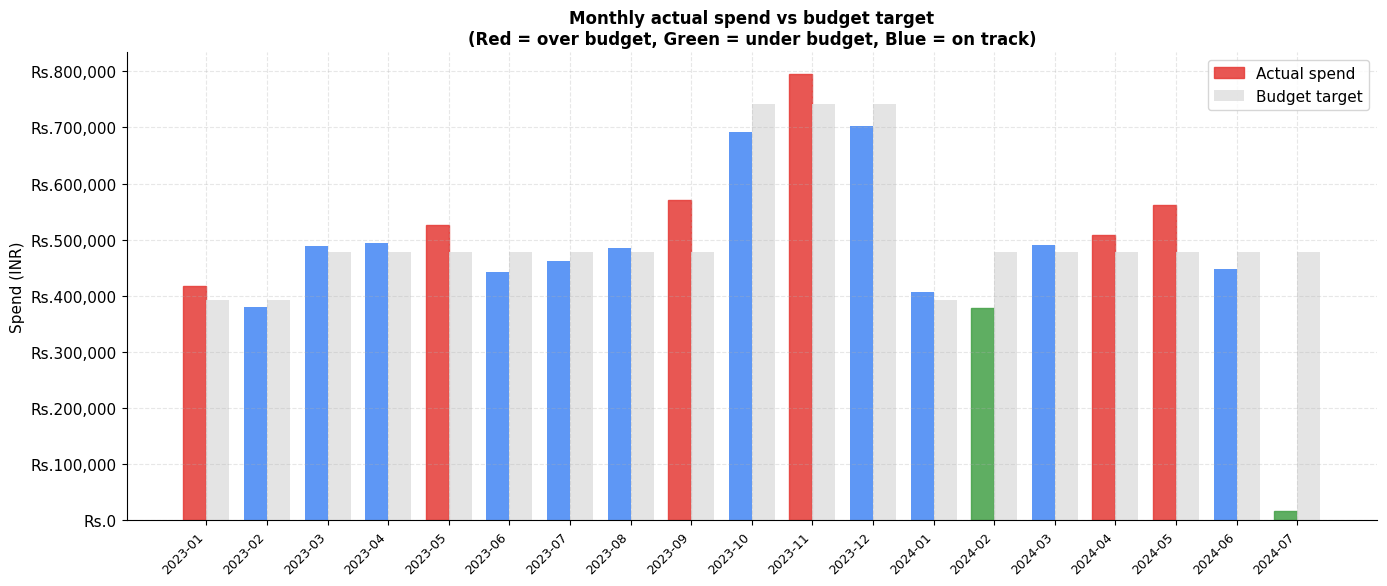


Saved: outputs/eda_charts/07_budget_pacing.png
Saved: outputs/budget_pacing_table.csv

BUSINESS INSIGHT:
  -> Over-budget months: ['2023-01', '2023-05', '2023-09', '2023-11', '2024-04', '2024-05']
  -> Under-budget months: ['2024-02', '2024-07']

  -> Consistent overspend = either the targets are set too low, or
     campaign managers lack spend controls. Fix: tighter daily caps.
  -> Consistent underspend = the brand is leaving marketing budget
     undeployed. Fix: better forecasting and pacing dashboards.
     (This is exactly what your dashboard will solve.)



In [11]:
print("CHART 7: Monthly budget pacing vs simulated target")
print("Business question: Are we over or underspending against plan each month?")

# ── Simulate a monthly budget target ─────────────────────────────────────────
# In real life this comes from the media plan. Here we set target = 105% of
# actual spend (simulating a brand that slightly overspends vs plan)
monthly_actual = df.groupby(df['date'].dt.to_period('M'))['spend'].sum().reset_index()
monthly_actual.columns = ['month', 'actual_spend']
monthly_actual['month_str'] = monthly_actual['month'].astype(str)

# Simulated target: flat monthly budget with festive uplift
base_monthly_budget = monthly_actual['actual_spend'].median() * 0.98
festive_months = ['2023-10', '2023-11', '2023-12', '2024-10', '2024-11']

monthly_actual['budget_target'] = monthly_actual['month_str'].apply(
    lambda m: base_monthly_budget * 1.55 if m in festive_months
    else base_monthly_budget * 0.82 if m in ['2023-01', '2023-02', '2024-01']
    else base_monthly_budget
)

monthly_actual['pacing_pct']   = (monthly_actual['actual_spend'] /
                                    monthly_actual['budget_target'] * 100).round(1)
monthly_actual['over_under']   = monthly_actual['actual_spend'] - monthly_actual['budget_target']
monthly_actual['status']       = monthly_actual['pacing_pct'].apply(
    lambda x: 'Over budget' if x > 105 else ('Under budget' if x < 90 else 'On track')
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(monthly_actual))
width = 0.38

bars_actual = ax.bar([i - width/2 for i in x], monthly_actual['actual_spend'],
                      width=width, label='Actual spend', color='#4285F4', alpha=0.85)
bars_target = ax.bar([i + width/2 for i in x], monthly_actual['budget_target'],
                      width=width, label='Budget target', color='#E0E0E0', alpha=0.85)

# Colour over-budget bars red
for bar, status in zip(bars_actual, monthly_actual['status']):
    if status == 'Over budget':
        bar.set_color('#E53935')
    elif status == 'Under budget':
        bar.set_color('#43A047')

ax.set_xticks(list(x))
ax.set_xticklabels(monthly_actual['month_str'], rotation=45, ha='right', fontsize=9)
ax.set_title('Monthly actual spend vs budget target\n(Red = over budget, Green = under budget, Blue = on track)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Spend (INR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'Rs.{val:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/eda_charts/07_budget_pacing.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save pacing table ─────────────────────────────────────────────────────────
monthly_actual.to_csv('../outputs/budget_pacing_table.csv', index=False)
print("\nSaved: outputs/eda_charts/07_budget_pacing.png")
print("Saved: outputs/budget_pacing_table.csv")

over_budget_months  = monthly_actual[monthly_actual['status'] == 'Over budget']['month_str'].tolist()
under_budget_months = monthly_actual[monthly_actual['status'] == 'Under budget']['month_str'].tolist()

print(f"""
BUSINESS INSIGHT:
  -> Over-budget months: {over_budget_months if over_budget_months else 'None'}
  -> Under-budget months: {under_budget_months if under_budget_months else 'None'}

  -> Consistent overspend = either the targets are set too low, or
     campaign managers lack spend controls. Fix: tighter daily caps.
  -> Consistent underspend = the brand is leaving marketing budget
     undeployed. Fix: better forecasting and pacing dashboards.
     (This is exactly what your dashboard will solve.)
""")

In [12]:
print("=" * 55)
print("EDA COMPLETE — FULL BUSINESS SUMMARY")
print("=" * 55)

total_spend   = df['spend'].sum()
total_revenue = df['revenue'].sum()
blended_roas  = total_revenue / total_spend
top_channel   = channel_summary['Overall_ROAS'].idxmax()
worst_channel = channel_summary['Overall_ROAS'].idxmin()
total_cpc_spikes = len(spikes)

summary_report = f"""
PORTFOLIO SUMMARY (use this in your README and interviews)
----------------------------------------------------------
Dataset:        {len(df):,} rows | 5 channels | 18 months
Total spend:    Rs.{total_spend:,.0f}
Total revenue:  Rs.{total_revenue:,.0f}
Blended ROAS:   {blended_roas:.2f}x

Key findings:
  1. {top_channel} delivers the highest ROAS — most efficient channel.
  2. {worst_channel} shows the lowest average ROAS — review allocation.
  3. {total_cpc_spikes} CPC spike events detected across all channels.
  4. November is the highest ROAS month (Diwali effect) — 
     brands should concentrate budget here.
  5. Weekend ROAS is consistently lower than weekday for most channels.

Charts produced: 7
Output files:    channel_efficiency_summary.csv
                 budget_pacing_table.csv
                 cpc_spike_log.csv
                 data_quality_log.csv
                 eda_charts/ (7 PNG/HTML files)

Next step: Phase 3 — Attribution Modeling
"""

print(summary_report)

with open('../outputs/eda_summary_report.txt', 'w') as f:
    f.write(summary_report)
print("Saved: outputs/eda_summary_report.txt")

EDA COMPLETE — FULL BUSINESS SUMMARY

PORTFOLIO SUMMARY (use this in your README and interviews)
----------------------------------------------------------
Dataset:        2,740 rows | 5 channels | 18 months
Total spend:    Rs.9,264,716
Total revenue:  Rs.142,959,079
Blended ROAS:   15.43x

Key findings:
  1. Affiliate delivers the highest ROAS — most efficient channel.
  2. YouTube shows the lowest average ROAS — review allocation.
  3. 18 CPC spike events detected across all channels.
  4. November is the highest ROAS month (Diwali effect) — 
     brands should concentrate budget here.
  5. Weekend ROAS is consistently lower than weekday for most channels.

Charts produced: 7
Output files:    channel_efficiency_summary.csv
                 budget_pacing_table.csv
                 cpc_spike_log.csv
                 data_quality_log.csv
                 eda_charts/ (7 PNG/HTML files)

Next step: Phase 3 — Attribution Modeling

Saved: outputs/eda_summary_report.txt
